In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore')

SEED = 42

df = pd.read_csv(
    '../datos/dataset_nlp_utf16_final.csv', 
    encoding='utf-16', 
    sep=',', 
    quoting=csv.QUOTE_ALL, 
    escapechar='\\'
)

# Unificación de textos para comparar
# Esto evita que un NaN destruya el texto de la otra columna al concatenarlos (sumarlos)
# Ejemplo de error anterior ("Conocimientos en Excel" + NaN = NaN)
df['cargo'] = df['cargo'].fillna('')
df['funciones'] = df['funciones'].fillna('')
df['conocimientos'] = df['conocimientos'].fillna('')
df['experiencia'] = df['experiencia'].fillna('')
df['experiencia_cv'] = df['experiencia_cv'].fillna('')
df['estudios_cv'] = df['estudios_cv'].fillna('')

# Juntamos lo que pide la empresa
df['texto_oferta'] = df['cargo'] + " " + df['funciones'] + " " + df['conocimientos'] + " " + df['experiencia']
# Juntamos lo que ofrece el candidato
df['texto_candidato'] = df['experiencia_cv'] + " " + df['estudios_cv']

# Trabajaremos los textos en minúsculas
df['texto_oferta'] = df['texto_oferta'].fillna('').str.lower()
df['texto_candidato'] = df['texto_candidato'].fillna('').str.lower()

print(f"Total de registros listos para análisis: {df.shape[0]}")

/usr/local/lib/python3.11/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


Total de registros listos para análisis: 220


In [2]:
# Trabajo adaptado para texto en español
import nltk
from nltk.corpus import stopwords


nltk.download('stopwords')  # Descarga del paquete de stop words
stop_words_es = stopwords.words('spanish')  # Crea una lista con las palabras vacías en español

print("Vectorizando textos con TF-IDF en español.")

vectorizador = TfidfVectorizer(max_features=5000, stop_words=stop_words_es)

# Ajusta el vocabulario usando tanto las ofertas como los CVs
corpus_completo = pd.concat([df['texto_oferta'], df['texto_candidato']])
vectorizador.fit(corpus_completo)

# Transforma textos a matrices numéricas
tfidf_ofertas = vectorizador.transform(df['texto_oferta'])
tfidf_candidatos = vectorizador.transform(df['texto_candidato'])

# Calcula la similitud del coseno fila por fila
similitudes = []
for i in range(df.shape[0]):
    # Calcula qué tan cerca está el vector del CV al vector de la Oferta (1 = Idéntico, 0 = Ninguna similitud)
    similitud = cosine_similarity(tfidf_ofertas[i], tfidf_candidatos[i])[0][0]
    similitudes.append(similitud)

df['score_similitud'] = similitudes
print("Similitud calculada. Muestra de los primeros 5 scores:")
print(df[['target_elegibilidad', 'score_similitud']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Vectorizando textos con TF-IDF en español.
Similitud calculada. Muestra de los primeros 5 scores:
   target_elegibilidad  score_similitud
0                    1         0.064945
1                    1         0.052568
2                    1         0.033694
3                    1         0.000000
4                    1         0.211424


In [3]:
# Calcula cantidades y porcentajes
total_filas = len(df)
filas_cero = (df['score_similitud'] == 0.0).sum()
porcentaje_ceros = (filas_cero / total_filas) * 100

print(f"Total de registros evaluados: {total_filas}")
print(f"Registros con similitud exacta de 0.0: {filas_cero}")
print(f"Porcentaje de ceros en el dataset: {porcentaje_ceros:.2f}%\n")

Total de registros evaluados: 220
Registros con similitud exacta de 0.0: 54
Porcentaje de ceros en el dataset: 24.55%



In [4]:
print("Iniciando entrenamiento del modelo de Línea Base.\n")

X = df[['score_similitud']]
y = df['target_elegibilidad'].astype(int)   # binario: 1 (Elegible) o 0 (No Elegible)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Datos para entrenar: {len(X_train)} filas.")
print(f"Datos para evaluar: {len(X_test)} filas.\n")

modelo_base = LogisticRegression(class_weight='balanced')
modelo_base.fit(X_train, y_train)

y_pred = modelo_base.predict(X_test)

Iniciando entrenamiento del modelo de Línea Base.

Datos para entrenar: 176 filas.
Datos para evaluar: 44 filas.



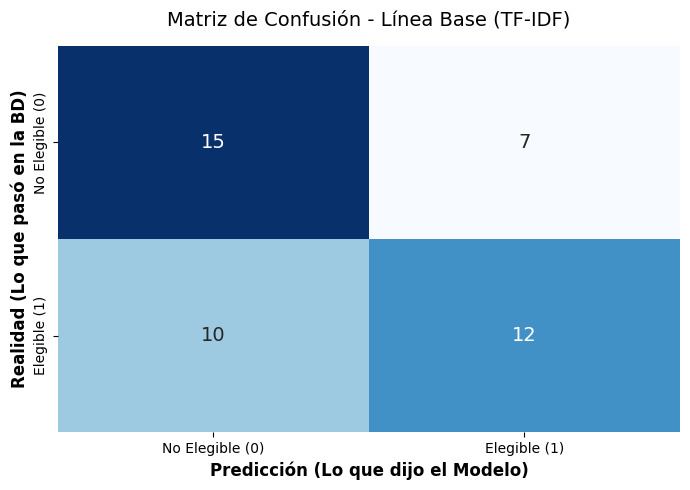

In [5]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Elegible (0)', 'Elegible (1)'],
            yticklabels=['No Elegible (0)', 'Elegible (1)'],
            annot_kws={"size": 14})

plt.title('Matriz de Confusión - Línea Base (TF-IDF)', fontsize=14, pad=15)
plt.ylabel('Realidad (Lo que pasó en la BD)', fontsize=12, fontweight='bold')
plt.xlabel('Predicción (Lo que dijo el Modelo)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
print(" RESULTADOS DE LA LÍNEA BASE [TF-IDF + (Regresión Logística - emplea función sigmoide)]")
print("Reporte de Clasificación Detallado (Precision, Recall, F1-score):")
print(classification_report(y_test, y_pred))

 RESULTADOS DE LA LÍNEA BASE [TF-IDF + (Regresión Logística - emplea función sigmoide)]
Reporte de Clasificación Detallado (Precision, Recall, F1-score):
              precision    recall  f1-score   support

           0       0.60      0.68      0.64        22
           1       0.63      0.55      0.59        22

    accuracy                           0.61        44
   macro avg       0.62      0.61      0.61        44
weighted avg       0.62      0.61      0.61        44



In [7]:
print("Cargando el modelo de lenguaje pre-entrenado (Multilingüe/Español).")
modelo_emb = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

Cargando el modelo de lenguaje pre-entrenado (Multilingüe/Español).


In [8]:
print("Generando vectores densos (embeddings) para ofertas y candidatos.")
embeddings_ofertas = modelo_emb.encode(df['texto_oferta'].tolist(), show_progress_bar=True)
embeddings_candidatos = modelo_emb.encode(df['texto_candidato'].tolist(), show_progress_bar=True)

Generando vectores densos (embeddings) para ofertas y candidatos.


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

In [9]:
# Calcula la nueva similitud del coseno basada en el contexto semántico
similitudes_semanticas = []
for i in range(df.shape[0]):
    similitud = cosine_similarity([embeddings_ofertas[i]], [embeddings_candidatos[i]])[0][0]
    similitudes_semanticas.append(similitud)

df['score_semantico'] = similitudes_semanticas

print("\nSimilitud semántica calculada. Comparativa de los primeros 5 scores:")
print(df[['target_elegibilidad', 'score_similitud', 'score_semantico']].head())


Similitud semántica calculada. Comparativa de los primeros 5 scores:
   target_elegibilidad  score_similitud  score_semantico
0                    1         0.064945         0.456486
1                    1         0.052568         0.436292
2                    1         0.033694         0.483938
3                    1         0.000000         0.409943
4                    1         0.211424         0.360955


In [10]:
print("Iniciando entrenamiento del modelo con la nueva Variante.")
X_sem = df[['score_semantico']]
y_sem = df['target_elegibilidad'].astype(int)

X_train_sem, X_test_sem, y_train_sem, y_test_sem = train_test_split(
    X_sem, y_sem, test_size=0.2, random_state=SEED, stratify=y_sem
)

# Se mantiene la Regresión Logística para poder hacer una comparación justa
modelo_variante = LogisticRegression(class_weight='balanced')
modelo_variante.fit(X_train_sem, y_train_sem)

y_pred_sem = modelo_variante.predict(X_test_sem)

print(" RESULTADOS DE LA VARIANTE (Embeddings + Regresión Logística)")
print("Reporte de Clasificación Detallado (Precision, Recall, F1-score):")
print(classification_report(y_test_sem, y_pred_sem))

Iniciando entrenamiento del modelo con la nueva Variante.
 RESULTADOS DE LA VARIANTE (Embeddings + Regresión Logística)
Reporte de Clasificación Detallado (Precision, Recall, F1-score):
              precision    recall  f1-score   support

           0       0.71      0.55      0.62        22
           1       0.63      0.77      0.69        22

    accuracy                           0.66        44
   macro avg       0.67      0.66      0.65        44
weighted avg       0.67      0.66      0.65        44



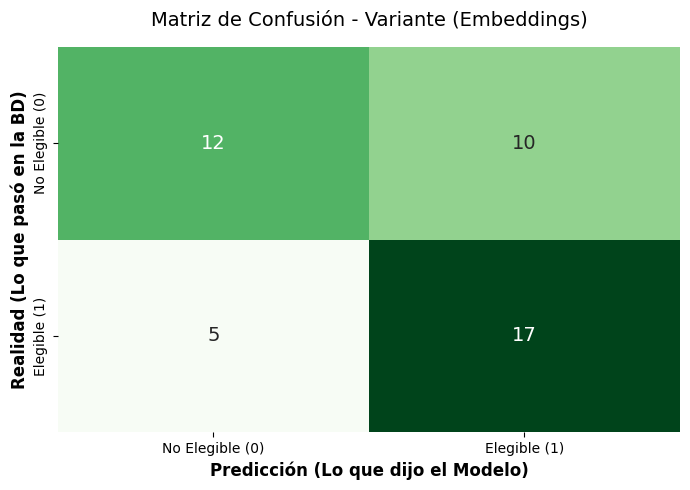

Reporte de Clasificación Detallado (Variante):
              precision    recall  f1-score   support

           0       0.71      0.55      0.62        22
           1       0.63      0.77      0.69        22

    accuracy                           0.66        44
   macro avg       0.67      0.66      0.65        44
weighted avg       0.67      0.66      0.65        44



In [11]:
cm_sem = confusion_matrix(y_test_sem, y_pred_sem)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_sem, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No Elegible (0)', 'Elegible (1)'],
            yticklabels=['No Elegible (0)', 'Elegible (1)'],
            annot_kws={"size": 14})

plt.title('Matriz de Confusión - Variante (Embeddings)', fontsize=14, pad=15)
plt.ylabel('Realidad (Lo que pasó en la BD)', fontsize=12, fontweight='bold')
plt.xlabel('Predicción (Lo que dijo el Modelo)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Reporte de Clasificación Detallado (Variante):")
print(classification_report(y_test_sem, y_pred_sem))